In [1]:
from lightkurve import DataCube, ErrorCube, DataFrame

%load_ext autoreload
%autoreload 2

In [2]:
from astropy.io import fits
import numpy as np

hdulist = fits.open(
    "./src/lightkurve/data/tess-s0001-4-2_84.291190_-80.469170_6x6_astrocut.fits"
)

# Prepare DataCube

In [3]:
flux_array = hdulist[1].data["FLUX"].astype(float)
flux_err_array = hdulist[1].data["FLUX_ERR"].astype(float)
time = hdulist[1].data["TIME"].astype(float)
time_corr = hdulist[1].data["TIMECORR"].astype(float)
c0, r0 = hdulist[1].header["1CRV4P"], hdulist[1].header["2CRV4P"]
row, col = np.arange(flux_array.shape[1]) + r0, np.arange(flux_array.shape[2]) + c0
aper = flux_array.mean(axis=0) > 10000
bkg_aper = flux_array.mean(axis=0) < 4000

time_mask = hdulist[1].data["QUALITY"] == 0

In [4]:
flux = DataCube(
    flux_array,
    time_indices={"btjd": time, "spacecraft_time": time - time_corr},
    row_indices={"row": row},
    col_indices={"column": col},
)

flux_err = ErrorCube(
    flux_err_array,
    time_indices={"btjd": time, "spacecraft_time": time - time_corr},
    row_indices={"row": row},
    col_indices={"column": col},
)

In [5]:
flux, flux_err

(📘 DataCube (500, 6, 6), 📕 ErrorCube (500, 6, 6))

# Tests

## Downsample

In [11]:
flux.downsample(5)

📘 DataCube (98, 6, 6)

In [12]:
flux_err.downsample(5)

📕 ErrorCube (98, 6, 6)

## Imposing an aperture mask where `mean`(flux of pixel) > 10,000

In [13]:
flux[:, aper]

,,series,8,9,14,15,16,19,20,21,22,25,26,27,28,31,32,33,34
,,row,258,258,259,259,259,260,260,260,260,261,261,261,261,262,262,262,262
,,column,1630,1631,1630,1631,1632,1629,1630,1631,1632,1629,1630,1631,1632,1629,1630,1631,1632
cadence,btjd,spacecraft_time,,,,,,,,,,,,,,,,,
0,1325.324261,1325.323506,42657.632812,65179.886719,100720.773438,101675.906250,42470.730469,29425.457031,102240.070312,103746.945312,61337.554688,26175.996094,103074.070312,105171.984375,40686.078125,11072.824219,102138.585938,104423.625000,10715.317383
1,1325.345094,1325.344340,42648.261719,65202.703125,100720.617188,101675.750000,42489.433594,29410.039062,102239.914062,103746.789062,61370.964844,26143.367188,103073.914062,105171.820312,40717.785156,11068.058594,102138.429688,104423.468750,10720.024414
2,1325.365927,1325.365173,42482.433594,65449.781250,100720.492188,101689.953125,42563.906250,29321.394531,102246.984375,103753.929688,61504.335938,26041.806641,103073.796875,105179.046875,40789.992188,11046.513672,102138.304688,104430.640625,10729.130859
3,1325.386761,1325.386006,42606.925781,65420.988281,100713.601562,101675.585938,42549.976562,29406.074219,102240.031250,103746.632812,61454.304688,26063.630859,103066.804688,105164.296875,40812.726562,11046.653320,102131.343750,104423.312500,10736.232422
4,1325.407594,1325.406840,42386.238281,65640.031250,100706.531250,101682.976562,42573.464844,29310.171875,102232.921875,103739.585938,61588.140625,25998.742188,103059.632812,105164.523438,40953.453125,11042.083008,102124.218750,104416.218750,10752.752930
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,1335.636671,1335.636002,36934.218750,65180.039062,100492.656250,101640.187500,42098.429688,27963.123047,102182.828125,103710.726562,62753.433594,25732.408203,103023.632812,105127.960938,43352.878906,11021.060547,102095.632812,104394.531250,11190.494141


## Sum of flux in aperture, per cadence

In [14]:
flux[:, aper].sum(axis=1)

📉 DataSeries (500,)
cadence  btjd         spacecraft_time
0        1325.324261  1325.323506        1.152913e+06
1        1325.345094  1325.344340        1.152961e+06
2        1325.365927  1325.365173        1.153162e+06
3        1325.386761  1325.386006        1.153259e+06
4        1325.407594  1325.406840        1.153372e+06
                                             ...     
495      1335.636671  1335.636002        1.148894e+06
496      1335.657504  1335.656835        1.148592e+06
497      1335.678338  1335.677669        1.149015e+06
498      1335.699171  1335.698502        1.148533e+06
499      1335.720004  1335.719335        1.148730e+06
Length: 500, dtype: float64

## Sum of flux error in aperture, per cadence. 

In [15]:
flux_err[:, aper].sum(axis=1)

📈 ErrorSeries (500,)
cadence  btjd         spacecraft_time
0        1325.324261  1325.323506        29.298033
1        1325.345094  1325.344340        29.298598
2        1325.365927  1325.365173        29.301073
3        1325.386761  1325.386006        29.302346
4        1325.407594  1325.406840        29.303881
                                           ...    
495      1335.636671  1335.636002        29.247717
496      1335.657504  1335.656835        29.244172
497      1335.678338  1335.677669        29.249303
498      1335.699171  1335.698502        29.243259
499      1335.720004  1335.719335        29.245815
Length: 500, dtype: float64

# Check types when transformed

In [16]:
type(flux), type(flux_err)

(lightkurve.datacube.DataCube, lightkurve.datacube.ErrorCube)

In [17]:
type(flux[:, aper]), type(flux_err[:, aper])

(lightkurve.dataframe.DataFrame, lightkurve.dataframe.ErrorFrame)

In [18]:
type(flux[:, 0, :]), type(flux_err[:, 0, :])
type(flux[:, :, 0]), type(flux_err[:, :, 0])

(lightkurve.dataframe.DataFrame, lightkurve.dataframe.ErrorFrame)

In [19]:
type(flux[:, 0, 0]), type(flux_err[:, 0, 0])

(lightkurve.dataframe.DataFrame, lightkurve.dataframe.ErrorFrame)

In [20]:
type(flux[:, aper].sum(axis=0)), type(flux_err[:, aper].sum(axis=0))
type(flux[:, aper].sum(axis=1)), type(flux_err[:, aper].sum(axis=1))

(lightkurve.dataseries.DataSeries, lightkurve.dataseries.ErrorSeries)

# Plot the light curve

<ErrorbarContainer object of 3 artists>

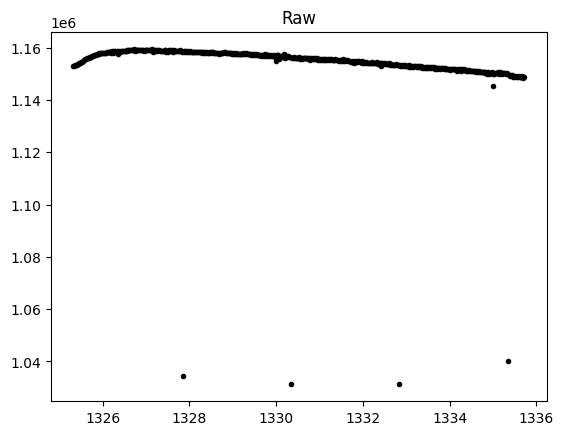

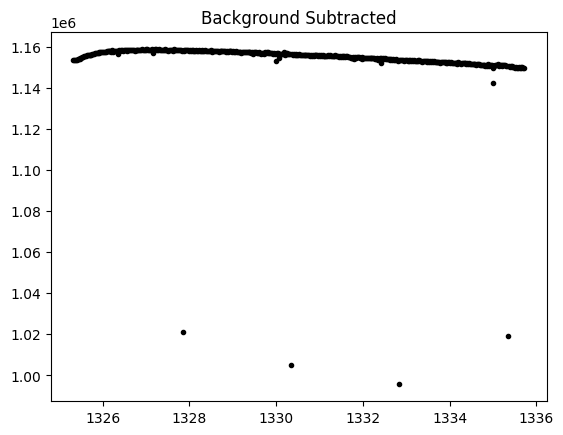

In [22]:
time = np.asarray(flux.btjd)
bkg = flux[:, bkg_aper].mean(axis=1)
bkg_err = flux_err[:, bkg_aper].mean(axis=1)

bkg -= bkg.median()

lc = flux[:, aper].sum(axis=1)
lc_err = flux_err[:, aper].sum(axis=1)

plt.figure()
plt.title("Raw")
plt.errorbar(time, lc.values, lc_err.values, ls='', marker='.', c='k')
# plt.ylim(.88e6, .94e6)

lc = flux[:, aper].sum(axis=1) - (bkg * aper.sum())
lc_err = flux_err[:, aper].sum(axis=1) + (bkg_err * aper.sum())

plt.figure()
plt.title("Background Subtracted")
plt.errorbar(time, lc.values, lc_err.values, ls='', marker='.', c='k')
# plt.ylim(0.88e6, 0.94e6)

## Info

repo: https://github.com/tessgi/secret/tree/christina-sketch1/src/lightkurve

# Milestones;

- ✅ Break the Cube, Frame, and Series classes into their own modules (cube.py, frame.py, series.py)
- ✅ Convert these demo functions into tests inside the package to fully test the functionality as users of lightkurve would need it. As you find any tests (breaking or passing) that cover functionality users need, add them to the tests.
    - ✅ To do this you will need to choose a reasonable piece of test data we can ship with the package. Crucially this must be small (ideally kb). You can trim down some tesscut data using lightkurve to add to the package
    - ❓ Confirm adjusted data product is appropriate and sufficient for tests
- ✅ Take a look at the pandas documentation and see if we can safely quiet the user warning that we have for adding our convenience functions (e.g. `flux.cadence`)
    - 🗒️ Add convenience functions to _metadata namespace
    - ❗️ Don't add existing attributes to this namespace, it messes up pandas at the core level somehow
- Currently there is an aggregate method for time. Create a similar aggregate method that will instead aggregate on columns so that;
    - ✅ DataCube.spatial_aggregate(...) -> returns a lower resolution datacube. e.g. sums pixels in row and column direction to create a lower resolution image
    - ✅ DataFrame.spatial_aggregate(...) -> returns a lower resolution dataframe
    - ✅ DataSeries has no spatial axis to aggregate
    - Create functions for ErrorCube and ErrorFrame

- We'll come back to; can we have in lightkurve3 a way to take cubes, frames, series and convert to fits imagehdu, tablehdu, and columnhdu. 

## Smaller test data

In [ ]:
from lksearch import TESSSearch
from astropy.coordinates import SkyCoord

search_input = (84.291190, -80.469170)
search_input = SkyCoord(*search_input, unit="deg", frame="icrs")
search_result = TESSSearch(search_input, hlsp=False)

# You can filter two different ways to get the same result.
# search_result.filter_table(pipeline='TESScut')
downloads_table = search_result.tesscut.filter_table(sector=1).download(TESScut_size=6)
hdulist = fits.open(downloads_table["Local Path"][0])

In [9]:
hdulist = fits.open(
    "/Users/dkgiles/.lksearch/cache/mastDownload/TESSCut/tess-s0001-4-2_84.291190_-80.469170_6x6_astrocut.fits"
)

In [68]:
hdulist[1].data = hdulist[1].data[:500]

In [69]:
hdulist.writeto(
    "./src/lightkurve/data/tess-s0001-4-2_84.291190_-80.469170_6x6_astrocut.fits"
)

## Spatial aggregation

In [6]:
def single_cadence_frame(datacube, cadence):
    return DataFrame(
        datacube.to_array()[cadence],
        index=datacube.row[:: datacube.nrow],
        columns=datacube.column[: datacube.ncol],
    )

In [7]:
flux

📘 DataCube (500, 6, 6)

In [8]:
flux_lowres = flux.spatial_aggregate(3, 3)
flux_lowres

📘 DataCube (500, 3, 3)

In [9]:
single_cadence_frame(flux_lowres, 0)

,1628.5,1630.5,1632.5
257.5,6432.709045,109930.779541,19585.473389
259.5,45785.497559,408383.695312,119838.886719
261.5,44921.303223,414808.265625,59080.133789


In [10]:
df0 = single_cadence_frame(flux, 0)
df0

,1628,1629,1630,1631,1632,1633
257,972.539368,965.366943,938.845215,1154.414795,1616.280029,2285.411133
258,2091.041260,2403.761475,42657.632812,65179.886719,8305.186523,7378.595703
259,4117.913574,6243.910156,100720.773438,101675.906250,42470.730469,8941.966797
260,5998.216797,29425.457031,102240.070312,103746.945312,61337.554688,7088.634766
261,4179.137207,26175.996094,103074.070312,105171.984375,40686.078125,4181.030273
262,3493.345703,11072.824219,102138.585938,104423.625000,10715.317383,3497.708008


In [19]:
print(f"Sum of first 2x2: {df0.iloc[:2, :2].sum().sum()}")
df0.iloc[:2, :2]

Sum of first 2x2: 6432.709045410156


,1628,1629
257,972.539368,965.366943
258,2091.041260,2403.761475
